# H1: fitting f_N vs N -- fitting_range dataset only

Careful analysis tied to a specific result -- pinned to run
`frozen_fraction_fitting_range_20260912T102036Z`
(N = 10,000..300,000, 20 points, target relative SE = 1%, all
realizations converged).

This uses the fitting_range dataset alone (not combined with the
earlier 100..102400 production dataset -- researcher's explicit choice,
2026-09-13). Note: since N>=10,000 everywhere here, the power-law
correction a/N^alpha is already small at every point in this range, so
this dataset mostly constrains f_inf tightly and may not constrain
a/alpha well -- that's a property of the data, not pre-judged here.

Same two models as `h1_fit_frozen_fraction.ipynb`, both fit by weighted
least squares using the per-N standard errors (sigma_N = SE):

- **Model 1 (constant):** f(N) = f_inf  (1 parameter)
- **Model 2 (power-law correction):** f(N) = f_inf + a / N^alpha  (3 parameters)

chi^2 = sum( ((f_N - model(N)) / sigma_N)^2 ), reduced chi^2 = chi^2 / dof,
dof = (number of points) - (number of parameters).

Presented as-is -- no claim here about which model is "correct".

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

RUN_DIR = Path('../../data/raw/frozen_fraction_fitting_range_20260912T102036Z')

with open(RUN_DIR / 'summary.json') as f:
    summary = json.load(f)
summary = sorted(summary, key=lambda row: row['L'])

N = np.array([row['L'] for row in summary], dtype=float)
f = np.array([row['frozen_fraction_mean'] for row in summary])
se = np.array([row['frozen_fraction_se'] for row in summary])

for n_i, f_i, se_i in zip(N, f, se):
    print(f"N={int(n_i):6d}  f_N={f_i:.4f} +- {se_i:.4f}")

N= 10000  f_N=0.3602 +- 0.0029
N= 25264  f_N=0.3577 +- 0.0015
N= 40526  f_N=0.3610 +- 0.0013
N= 55790  f_N=0.3601 +- 0.0013
N= 71054  f_N=0.3598 +- 0.0010
N= 86316  f_N=0.3612 +- 0.0011
N=101580  f_N=0.3591 +- 0.0010
N=116842  f_N=0.3595 +- 0.0007
N=132106  f_N=0.3590 +- 0.0006
N=147368  f_N=0.3595 +- 0.0006
N=162632  f_N=0.3618 +- 0.0006
N=177896  f_N=0.3598 +- 0.0008
N=193158  f_N=0.3601 +- 0.0006
N=208422  f_N=0.3600 +- 0.0005
N=223684  f_N=0.3593 +- 0.0005
N=238948  f_N=0.3602 +- 0.0006
N=254212  f_N=0.3593 +- 0.0006
N=269474  f_N=0.3607 +- 0.0005
N=284738  f_N=0.3596 +- 0.0006
N=300000  f_N=0.3601 +- 0.0005


In [2]:
def chi_square(f_obs, f_model, sigma):
    return np.sum(((f_obs - f_model) / sigma) ** 2)

n_points = len(N)

# --- Model 1: constant f_inf ---
weights = 1.0 / se**2
f_inf_const = np.sum(f * weights) / np.sum(weights)
f_inf_const_err = np.sqrt(1.0 / np.sum(weights))

model1_pred = np.full_like(f, f_inf_const)
model1_resid = f - model1_pred
model1_chi2 = chi_square(f, model1_pred, se)
model1_dof = n_points - 1
model1_red_chi2 = model1_chi2 / model1_dof

print('Model 1: constant f(N) = f_inf')
print(f'  f_inf = {f_inf_const:.5f} +- {f_inf_const_err:.5f}')
print(f'  chi^2 = {model1_chi2:.3f}, dof = {model1_dof}, reduced chi^2 = {model1_red_chi2:.3f}')
print('  residuals (f_N - f_inf):')
for n_i, r_i in zip(N, model1_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 1: constant f(N) = f_inf
  f_inf = 0.35992 +- 0.00015
  chi^2 = 23.254, dof = 19, reduced chi^2 = 1.224
  residuals (f_N - f_inf):
    N= 10000  residual=+0.00024
    N= 25264  residual=-0.00227
    N= 40526  residual=+0.00110
    N= 55790  residual=+0.00014
    N= 71054  residual=-0.00011
    N= 86316  residual=+0.00129
    N=101580  residual=-0.00078
    N=116842  residual=-0.00041
    N=132106  residual=-0.00092
    N=147368  residual=-0.00039
    N=162632  residual=+0.00183
    N=177896  residual=-0.00011
    N=193158  residual=+0.00018
    N=208422  residual=+0.00005
    N=223684  residual=-0.00066
    N=238948  residual=+0.00025
    N=254212  residual=-0.00063
    N=269474  residual=+0.00081
    N=284738  residual=-0.00037
    N=300000  residual=+0.00015


In [3]:
# --- Model 2: f_inf + a / N^alpha ---
def model2(n, f_inf, a, alpha):
    return f_inf + a / n**alpha

p0 = [f_inf_const, f[0] - f_inf_const, 1.0]
popt, pcov = curve_fit(model2, N, f, p0=p0, sigma=se, absolute_sigma=True, maxfev=20000)
f_inf_m2, a_m2, alpha_m2 = popt
perr = np.sqrt(np.diag(pcov))

model2_pred = model2(N, *popt)
model2_resid = f - model2_pred
model2_chi2 = chi_square(f, model2_pred, se)
model2_dof = n_points - 3
model2_red_chi2 = model2_chi2 / model2_dof

print('Model 2: f(N) = f_inf + a / N^alpha')
print(f'  f_inf = {f_inf_m2:.5f} +- {perr[0]:.5f}')
print(f'  a     = {a_m2:.5f} +- {perr[1]:.5f}')
print(f'  alpha = {alpha_m2:.5f} +- {perr[2]:.5f}')
print(f'  chi^2 = {model2_chi2:.3f}, dof = {model2_dof}, reduced chi^2 = {model2_red_chi2:.3f}')
print('  residuals (f_N - model2(N)):')
for n_i, r_i in zip(N, model2_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 2: f(N) = f_inf + a / N^alpha
  f_inf = 0.35992 +- inf
  a     = 0.39379 +- inf
  alpha = 127.46483 +- inf
  chi^2 = 23.254, dof = 17, reduced chi^2 = 1.368
  residuals (f_N - model2(N)):
    N= 10000  residual=+0.00024
    N= 25264  residual=-0.00227
    N= 40526  residual=+0.00110
    N= 55790  residual=+0.00014
    N= 71054  residual=-0.00011
    N= 86316  residual=+0.00129
    N=101580  residual=-0.00078
    N=116842  residual=-0.00041
    N=132106  residual=-0.00092
    N=147368  residual=-0.00039
    N=162632  residual=+0.00183
    N=177896  residual=-0.00011
    N=193158  residual=+0.00018
    N=208422  residual=+0.00005
    N=223684  residual=-0.00066
    N=238948  residual=+0.00025
    N=254212  residual=-0.00063
    N=269474  residual=+0.00081
    N=284738  residual=-0.00037
    N=300000  residual=+0.00015


/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_16153/3864288346.py:3: RuntimeWarning: overflow encountered in power
  return f_inf + a / n**alpha
/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_16153/3864288346.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model2, N, f, p0=p0, sigma=se, absolute_sigma=True, maxfev=20000)


In [4]:
print(f"{'model':<12} {'params':<55} {'chi2':>8} {'dof':>4} {'red chi2':>9}")
print(f"{'constant':<12} {'f_inf='+format(f_inf_const,'.5f'):<55} {model1_chi2:8.3f} {model1_dof:4d} {model1_red_chi2:9.3f}")
params_str = f"f_inf={f_inf_m2:.5f}, a={a_m2:.5f}, alpha={alpha_m2:.5f}"
print(f"{'f_inf+a/N^a':<12} {params_str:<55} {model2_chi2:8.3f} {model2_dof:4d} {model2_red_chi2:9.3f}")

model        params                                                      chi2  dof  red chi2
constant     f_inf=0.35992                                             23.254   19     1.224
f_inf+a/N^a  f_inf=0.35992, a=0.39379, alpha=127.46483                 23.254   17     1.368


/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_16153/3864288346.py:3: RuntimeWarning: overflow encountered in power
  return f_inf + a / n**alpha


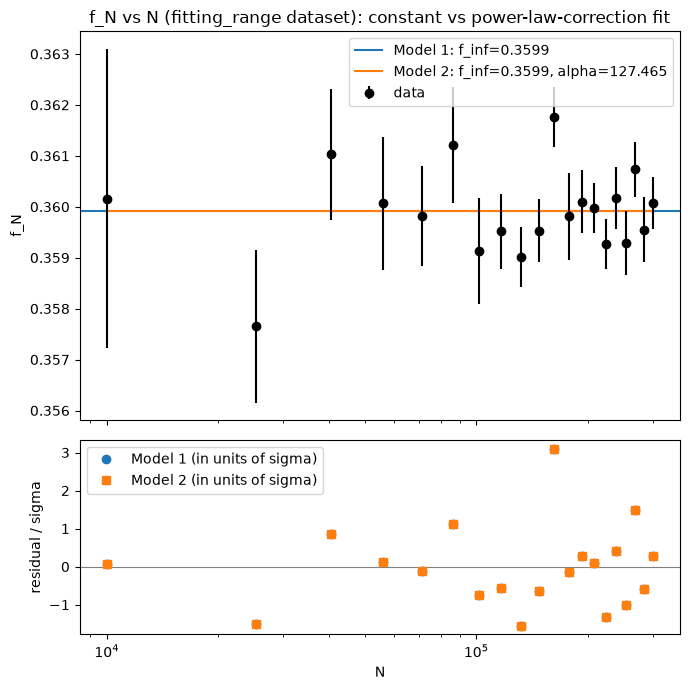

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True, height_ratios=[2, 1])

n_grid = np.geomspace(N.min(), N.max(), 200)

ax = axes[0]
ax.errorbar(N, f, yerr=se, fmt='o', color='black', label='data', zorder=3)
ax.axhline(f_inf_const, color='C0', label=f'Model 1: f_inf={f_inf_const:.4f}')
ax.plot(n_grid, model2(n_grid, *popt), color='C1',
        label=f'Model 2: f_inf={f_inf_m2:.4f}, alpha={alpha_m2:.3f}')
ax.set_xscale('log')
ax.set_ylabel('f_N')
ax.legend()
ax.set_title('f_N vs N (fitting_range dataset): constant vs power-law-correction fit')

ax = axes[1]
ax.axhline(0, color='gray', linewidth=0.8)
ax.errorbar(N, model1_resid / se, fmt='o', color='C0', label='Model 1 (in units of sigma)')
ax.errorbar(N, model2_resid / se, fmt='s', color='C1', label='Model 2 (in units of sigma)')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('residual / sigma')
ax.legend()

fig.tight_layout()
plt.show()